# **Proyecto Final: Predicción del abandono de clientes de una empresa de telecomunicaciones**

# Proyecto Final: Predicción del abandono de clientes de una empresa de telecomunicaciones

## Explicación del Proyecto
La pérdida de clientes (Customer Churn) es una de las problematicas más grandes para cualquier negocio por suscripción. Al final del día, perder usuarios no solo golpea los ingresos recurrentes, sino que encarece muchísimo la adquisición de nuevos clientes. Por eso, en este proyecto nos propusimos entender qué lleva a la gente a irse de la empresa analizando sus contratos, antigüedad y tarifas, para terminar armando un modelo predictivo que nos permita actuar a tiempo y retenerlos.

---

### Formulación del Problema de Machine Learning

* **Tipo de Tarea:** Clasificación Binaria Supervisada.
* **Variable Objetivo (Target):** `Churn` (1: El cliente abandona el servicio, 0: El cliente permanece).
* **Métrica de Éxito Principal:** **ROC-AUC** y **Recall** (Sensibilidad) para la clase positiva (`Churn`).

> **Justificación de Negocio para la Métrica:**
> ¿Por qué elegimos priorizar el Recall? Sencillo: en telecomunicaciones, retener a un cliente existente con una promoción o descuento sale muchísimo más barato que salir a buscar uno nuevo. Es preferible cometer el error de dar un beneficio de más a un cliente por error (falso positivo) antes que dejar ir a alguien que estaba a punto de cancelar y no percatarse de ello (falso negativo).

---

## Problema de negocio
La empresa registra un incremento en la tasa de cancelación sin contar con una herramienta para identificar previamente a los usuarios en riesgo. Actualmente, las acciones de fidelización se aplican de forma generalizada, lo que reduce su efectividad e incrementa los costos.

## Objetivo general
Desarrollar un modelo de clasificación para predecir qué clientes tienen mayor probabilidad de abandonar el servicio a partir de sus variables demográficas, financieras y de consumo.

## Preguntas de negocio
1. ¿Cuál es la tasa de cancelación de clientes?
2. ¿Qué características tienen los clientes que abandonan el servicio?
3. ¿Existe relación entre el tipo de contrato y la cancelación?
4. ¿Influye el tiempo que un cliente lleva en la empresa en la probabilidad de abandono?
5. ¿Los clientes con mayores cargos mensuales presentan un mayor riesgo de cancelar?
6. ¿Qué método de pago está asociado con una mayor tasa de abandono?
7. ¿Qué servicios generan mayor fidelización?
8. ¿Cuáles son las variables más importantes para predecir el churn?
9. ¿Qué segmentos de clientes presentan el mayor riesgo?
10. ¿Qué acciones podría implementar la empresa para reducir la pérdida de clientes?

## Hipótesis
* **H1:** Los clientes con contrato mensual (*Month-to-Month*) presentan mayor probabilidad de churn.
* **H2:** A menor antigüedad (*Tenure*), mayor riesgo de abandono.
* **H3:** Cargos mensuales más elevados están asociados a una mayor tasa de cancelación.
* **H4:** El pago mediante cheque electrónico (*Electronic Check*) registra la mayor tasa de pérdida de clientes.
* **H5:** La contratación de múltiples servicios reduce la probabilidad de churn.

---
## 1. **Carga de Datos y Limpieza Estructural Inicial**

En esta primera etapa se establecen las librerias a utilizar y la conexión con la fuente de datos almacenada en Google Drive y se realiza la lectura del dataset `WA_Fn-UseC_-Telco-Customer-Churn.csv`.


In [2]:
# ==========================================
# IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN GLOBAL
# ==========================================
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# Configuración global de estilos para gráficos
sns.set_style("whitegrid")
sns.set_context("notebook")

# Paleta de colores estándar para el proyecto (Azul: No Churn, Naranja/Rojo: Churn)
paleta_churn = {"No": "#1f77b4", "Yes": "#ff7f0e"}
sns.set_palette(list(paleta_churn.values()))

# Formato y tamaño de fuentes para legibilidad
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.figsize': (8, 5)
})

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Carga del dataset
ruta = '/content/drive/MyDrive/DATA SCIENCE/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(
    ruta,
    sep=',',
    engine='python',
    index_col=False,
    encoding='latin-1'
)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Para garantizar la integridad técnica antes de continuar con la exploración y el modelado, se realizó un diagnóstico preventivo del tipo de datos donde se detectó que la variable **`TotalCharges`** estaba clasificada como objeto (texto) debido a la presencia de **11 valores en blanco (`' '`)**.

In [4]:
# Limpieza estructural de TotalCharges (convertir 11 vacíos a NaN y eliminar)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)

# Verificación de dimensiones
print("Nulos restantes en TotalCharges:", df['TotalCharges'].isnull().sum())
print("Tipo de dato de TotalCharges:", df['TotalCharges'].dtype)
print("Forma del DataFrame limpio:", df.shape)

Nulos restantes en TotalCharges: 0
Tipo de dato de TotalCharges: float64
Forma del DataFrame limpio: (7032, 21)


**Acciones realizadas en esta fase:**
* Conversión forzada de `TotalCharges` a tipo numérico flotante (`float64`), transformando los 11 espacios en blanco en valores nulos (`NaN`).
* Eliminación de los 11 registros nulos generados, reduciendo la base de 7,043 a un total de **7,032 filas sin pérdida significativa de información**.
* Establecimiento del entorno visual con `Seaborn` y `Matplotlib` utilizando una paleta corporativa estándar para diferenciar clientes activos (`No Churn`) de clientes que abandonaron (`Churn`).

In [5]:
# Resumen del dataset
resumen_dataset = pd.DataFrame({
    "Característica": [
        "Cantidad de registros",
        "Cantidad de variables",
        "Variables numéricas",
        "Variables categóricas",
        "Valores nulos",
        "Registros duplicados"
    ],
    "Resultado": [
        df.shape[0],
        df.shape[1],
        df.select_dtypes(include=np.number).shape[1],
        df.select_dtypes(include="object").shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ]
})
display(resumen_dataset)

,Característica,Resultado
0,Cantidad de registros,7032
1,Cantidad de variables,21
2,Variables numéricas,4
3,Variables categóricas,17
4,Valores nulos,0
5,Registros duplicados,0


Con esta limpieza inicial, la base queda lista con **7,032 registros, 4 variables numéricas y 17 categóricas**, asegurando la coherencia en las consultas SQL y análisis posteriores.

# **Conclusión del Diagnóstico Inicial:**

El análisis exploratorio inicial confirma un volumen de **7,032 registros y 21 variables**. No se detectaron filas duplicadas ni valores nulos explícitos mediante `df.isnull()`.

---
## 2. **Análisis Exploratorio con SQL y Creación de Nuevas Variables**

In [6]:
# ==========================================
# CONEXIÓN Y CREACIÓN DE TABLA EN SQLITE
# ==========================================

import sqlite3

conexion = sqlite3.connect("telco_churn.db")
df.to_sql("telco_churn", conexion, if_exists="replace", index=False)

print("Conexión con SQLite establecida y tabla 'telco_churn' creada correctamente.")

Conexión con SQLite establecida y tabla 'telco_churn' creada correctamente.


In [7]:
query = """
SELECT name
FROM sqlite_master
WHERE type = 'table';
"""

tablas = pd.read_sql_query(query, conexion)

display(tablas)

,name
0,telco_churn


* Primeras Consultas con SQL:



In [8]:
# Pregunta de Negocio: ¿Cuántos clientes tiene la empresa?

query = """
SELECT COUNT(*) AS total_clientes
FROM telco_churn;
"""

resultado = pd.read_sql_query(query, conexion)

display(resultado)

,total_clientes
0,7032


In [9]:
# Pregunta de Negocio: ¿Cuántos clientes permanecieron y cuántos abandonaron?


query = """
SELECT
    Churn,
    COUNT(*) AS cantidad_clientes
FROM telco_churn
GROUP BY Churn
ORDER BY cantidad_clientes DESC;
"""

resultado_churn = pd.read_sql_query(query, conexion)

display(resultado_churn)

,Churn,cantidad_clientes
0,No,5163
1,Yes,1869


In [10]:
# Pregunta de Negocio: ¿Qué porcentaje de los clientes abandonó la empresa?
query = """
SELECT
    ROUND(100.0 * AVG(Churn = 'Yes'), 2) AS tasa_churn
FROM telco_churn;
"""
tasa_churn = pd.read_sql_query(query, conexion)
display(tasa_churn)

,tasa_churn
0,26.58


In [11]:
# Calcular Tasa de Churn por Tipo de Contrato
query = """
SELECT
    Contract,
    COUNT(*) AS total_clientes,
    SUM(Churn = 'Yes') AS clientes_churn,
    ROUND(100.0 * AVG(Churn = 'Yes'), 2) AS tasa_churn
FROM telco_churn
GROUP BY Contract
ORDER BY tasa_churn DESC;
"""

churn_contrato = pd.read_sql_query(query, conexion)
display(churn_contrato)

,Contract,total_clientes,clientes_churn,tasa_churn
0,Month-to-month,3875,1655,42.71
1,One year,1472,166,11.28
2,Two year,1685,48,2.85


In [12]:
# Pregunta de Negocio: ¿La antigüedad del cliente está relacionada con el abandono?
query = """
SELECT
    CASE
        WHEN tenure <= 12 THEN '0-12 meses'
        WHEN tenure <= 24 THEN '13-24 meses'
        WHEN tenure <= 48 THEN '25-48 meses'
        ELSE 'Más de 48 meses'
    END AS grupo_antiguedad,
    COUNT(*) AS total_clientes,
    SUM(Churn = 'Yes') AS clientes_churn,
    ROUND(100.0 * AVG(Churn = 'Yes'), 2) AS tasa_churn
FROM telco_churn
GROUP BY grupo_antiguedad
ORDER BY tasa_churn DESC;
"""
churn_tenure = pd.read_sql_query(query, conexion)
display(churn_tenure)

,grupo_antiguedad,total_clientes,clientes_churn,tasa_churn
0,0-12 meses,2175,1037,47.68
1,13-24 meses,1024,294,28.71
2,25-48 meses,1594,325,20.39
3,Más de 48 meses,2239,213,9.51


In [13]:
# Pregunta de Negocio: ¿Existe alguna relación entre el método de pago y el abandono?

query = """
SELECT
    PaymentMethod,
    COUNT(*) AS total_clientes,
    SUM(
        CASE
            WHEN Churn = 'Yes' THEN 1
            ELSE 0
        END
    ) AS clientes_churn,
    ROUND(
        100.0 * SUM(
            CASE
                WHEN Churn = 'Yes' THEN 1
                ELSE 0
            END
        ) / COUNT(*),
        2
    ) AS tasa_churn
FROM telco_churn
GROUP BY PaymentMethod
ORDER BY tasa_churn DESC;
"""

churn_pago = pd.read_sql_query(query, conexion)

display(churn_pago)

,PaymentMethod,total_clientes,clientes_churn,tasa_churn
0,Electronic check,2365,1071,45.29
1,Mailed check,1604,308,19.20
2,Bank transfer (automatic),1542,258,16.73
3,Credit card (automatic),1521,232,15.25


In [14]:
# Pregunta de Negocio: ¿Cuál es el cargo mensual promedio de los clientes que abandonaron y de los que permanecieron?

query = """
SELECT
    Churn,
    ROUND(AVG(MonthlyCharges), 2) AS cargo_mensual_promedio
FROM telco_churn
GROUP BY Churn;
"""

cargos_churn = pd.read_sql_query(query, conexion)

display(cargos_churn)

,Churn,cargo_mensual_promedio
0,No,61.31
1,Yes,74.44


In [15]:
# Principales Indicadores

query = """
SELECT
    COUNT(*) AS total_clientes,

    SUM(
        CASE
            WHEN Churn = 'Yes' THEN 1
            ELSE 0
        END
    ) AS clientes_churn,

    SUM(
        CASE
            WHEN Churn = 'No' THEN 1
            ELSE 0
        END
    ) AS clientes_activos,

    ROUND(
        100.0 * SUM(
            CASE
                WHEN Churn = 'Yes' THEN 1
                ELSE 0
            END
        ) / COUNT(*),
        2
    ) AS tasa_churn,

    ROUND(AVG(MonthlyCharges), 2) AS cargo_mensual_promedio

FROM telco_churn;
"""

kpis = pd.read_sql_query(query, conexion)

display(kpis)

,total_clientes,clientes_churn,clientes_activos,tasa_churn,cargo_mensual_promedio
0,7032,1869,5163,26.58,64.8


#**Interpretación del análisis mediante SQL:**
Las consultas SQL permitieron responder de forma preliminar las principales preguntas de negocio antes de realizar el EDA avanzado en Python:
Las consultas SQL realizadas revelan patrones claros en el comportamiento de la base de clientes (7,032 usuarios analizables):

* Tasa General de Churn: La empresa presenta una tasa global de cancelación del 26.58% (1,869 clientes perdidos).

* Impacto del Tipo de Contrato: Existe una marcada vulnerabilidad en los contratos mes a mes (Month-to-month), los cuales registran la mayor tasa de abandono (42.71%), frente a un 11.28% en contratos a un año y apenas un 2.85% en contratos a dos años.

* Factor Antigüedad (Tenure): Los clientes en su primer año (0 a 12 meses) concentran el nivel crítico de riesgo con un 47.68% de churn. Esta cifra disminuye progresivamente a medida que aumenta la permanencia, cayendo al 9.51% en usuarios con más de 48 meses.

* Método de Pago: El pago mediante cheque electrónico (Electronic check) está fuertemente asociado a la pérdida de usuarios, alcanzando una tasa de churn del 45.29%, superando por más del doble a los métodos automáticos como transferencia bancaria (16.73%) o tarjeta de crédito (15.25%).

* Cargos Mensuales: Los clientes que cancelaron el servicio pagaban en promedio $74.44 USD mensuales, un valor sustancialmente más alto que los $$61.31 USD promediados por los clientes que permanecieron activos.

El perfil del cliente con mayor riesgo de abandono corresponde a un usuario con menos de un año de antigüedad, contrato mes a mes, un cargo mensual elevado y pago vía cheque electrónico. Para mitigar este problema, las estrategias de retención deben enfocarse en incentivar la migración hacia contratos de mayor plazo y métodos de pago automáticos durante los primeros meses del ciclo de vida del cliente.

In [16]:
conexion.close()

print("Conexión con SQLite cerrada correctamente.")

Conexión con SQLite cerrada correctamente.


---


Antes de comenzar las transformaciones, vamos a mantener una copia de los datos
originales.
Esto nos permite conservar el dataset original y trabajar sobre una copia por si hay futuros inconvenientes al continuar con el analisis y reproducción del proyecto.

In [17]:
# ==========================================
# COPIA DEL DATASET ORIGINAL
# ==========================================

df_eda = df.copy()

print("Copia del dataset creada correctamente.")
print("Dimensiones:", df_eda.shape)

Copia del dataset creada correctamente.
Dimensiones: (7032, 21)


---

## 3. **Estadísticas Descriptivas y Análisis Exploratorio en Python**

Con el dataset limpio, procedemos a examinar la distribución estadística de las variables numéricas y categóricas sobre el total de 7,032 registros. Este análisis inicial nos permite identificar tendencias centrales, dispersión y posibles valores atípicos que puedan influir en el comportamiento del modelo:

* **Variables Cuantitativas** (describe()): Permiten evaluar la tendencia central (media y mediana), la desviación estándar y los rangos de las variables clave como la antigüedad (tenure), los cargos mensuales (MonthlyCharges) y el acumulado total (TotalCharges).

* **Variables Cualitativas** (describe(include='object')): Facilitan la identificación de la cardinalidad, los valores únicos y la categoría predominante dentro de cada característica cualitativa del negocio.


In [18]:
# ==========================================
# ESTADÍSTICAS DESCRIPTIVAS COMPLETAS
# ==========================================

# 1. Variables numéricas (incluye TotalCharges tras la limpieza)
print("--- RESUMEN DE VARIABLES NUMÉRICAS ---")
display(df_eda.describe().T)

# 2. Variables categóricas
print("\n--- RESUMEN DE VARIABLES CATEGÓRICAS ---")
display(df_eda.describe(include='object').T)

--- RESUMEN DE VARIABLES NUMÉRICAS ---


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7032.0,0.162400,0.368844,0.00,0.0000,0.000,0.0000,1.00
tenure,7032.0,32.421786,24.545260,1.00,9.0000,29.000,55.0000,72.00
MonthlyCharges,7032.0,64.798208,30.085974,18.25,35.5875,70.350,89.8625,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.4500,1397.475,3794.7375,8684.80



--- RESUMEN DE VARIABLES CATEGÓRICAS ---


,count,unique,top,freq
customerID,7032,7032,3186-AJIEK,1
gender,7032,2,Male,3549
Partner,7032,2,No,3639
Dependents,7032,2,No,4933
PhoneService,7032,2,Yes,6352
MultipleLines,7032,3,No,3385
InternetService,7032,3,Fiber optic,3096
OnlineSecurity,7032,3,No,3497
OnlineBackup,7032,3,No,3087
DeviceProtection,7032,3,No,3094


### Interpretación de las Estadísticas Descriptivas

**Variables Numéricas:**
* **Antigüedad (`tenure`):** La permanencia media de los clientes es de aproximadamente **32.4 meses** (con una mediana de 29 meses). La alta desviación estándar (**24.55 meses**) indica una marcada bimodalidad: existe un grupo considerable de clientes muy nuevos (el 25% tiene 9 meses o menos) y otro grupo consolidado cerca del máximo de **72 meses**.
* **Cargos Mensuales (`MonthlyCharges`):** El promedio mensual facturado es de **$$64.80 USD** (mediana de **$70.35 USD**), abarcando un rango que va desde **$18.25 USD** hasta **$118.75 USD**. Esto refleja una clara segmentación entre usuarios con servicios básicos de solo telefonía y usuarios con paquetes avanzados de fibra óptica y contenidos.
* **Cargos Totales (`TotalCharges`):** Presenta un valor medio acumulado de **$2,283.30 USD** con un máximo de **$8,684.80 USD**. La asimetría hacia la derecha es esperable, ya que está fuertemente supeditada a la combinación entre la antigüedad y la tarifa mensual.
* **Adultos Mayores (`SeniorCitizen`):** Solo el **16.24%** de la base de clientes corresponde a adultos mayores (representado como indicador binario 0/1).

**Variables Categóricas:**
* **Balance de Género:** La muestra está balanceada entre hombres (**50.47%**) y mujeres.
* **Servicio de Internet:** El servicio predominantemente contratado es **Fiber optic** (**3,096 clientes**), seguido por DSL.
* **Contrato y Pago:** La modalidad contractual más frecuente es **Month-to-month** (**3,875 clientes**), y el método de pago principal es **Electronic check** (**2,365 clientes**), ambos identificados previamente en el análisis SQL como factores críticos de churn.

---
## 4. **Variable Objetivo: (`Churn`)**

Ahora comenzamos a analizar la variable más importante del proyecto: **Churn**.

Antes de entrenar un modelo necesitamos saber si las clases están equilibradas. Si tenemos muchos más clientes 'No' que 'Yes', nos enfrentamos a un problema de clases desbalanceadas. Esto es crucial para la fase de modelado, ya que deberemos seleccionar métricas adecuadas (como Precision, Recall y F1-Score) en lugar de guiarnos únicamente por el Accuracy.

| Categoría (`Churn`) | Cantidad de Clientes | Porcentaje (%) |
| :--- | :---: | :---: |
| **No (Permanecen)** | 5,163 | 73.42% |
| **Yes (Abandonan)** | 1,869 | 26.58% |

,Cantidad,Porcentaje (%)
Churn,,
No,5163,73.42
Yes,1869,26.58


/tmp/ipykernel_3145/3415956893.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_eda, x='Churn', palette=paleta_churn)


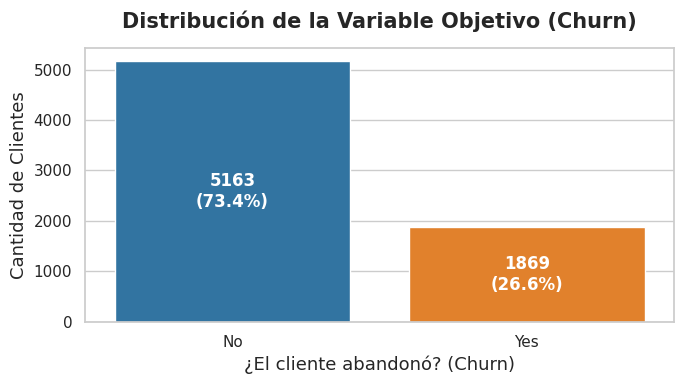

In [19]:
# ==========================================
# DISTRIBUCIÓN Y DESBALANCE DE LA VARIABLE TARGET
# ==========================================

# Tabla consolidada con conteo y porcentaje
distribucion_churn = pd.DataFrame({
    'Cantidad': df_eda['Churn'].value_counts(),
    'Porcentaje (%)': (df_eda['Churn'].value_counts(normalize=True) * 100).round(2)
})
display(distribucion_churn)

# Gráfico de barras visual
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df_eda, x='Churn', palette=paleta_churn)
plt.title('Distribución de la Variable Objetivo (Churn)', pad=15)
plt.xlabel('¿El cliente abandonó? (Churn)')
plt.ylabel('Cantidad de Clientes')

# Agregar etiquetas sobre las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}\n({p.get_height()/len(df_eda)*100:.1f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

#### Conclusiones del Análisis de la Variable Target:

- **Presencia de Desbalance Moderado:** Existe una proporción de aproximadamente **3 a 1** entre los clientes que permanecen (`No`: 73.42%) y los que abandonan (`Yes`: 26.58%).
- **Implicación para el Modelado:** Un modelo básico que prediga que *ningún cliente abandona* obtendría un **Accuracy del 73.42%**, pero sería inútil para el negocio porque no detectaría a nadie en riesgo. Por esta razón, la evaluación del modelo no se basará en el Accuracy, sino en métricas enfocadas en la clase positiva como **ROC-AUC** y **Recall** para capturar la mayor cantidad posible de clientes propensos a cancelar.

---
## 5. **Análisis de Variable: Tenure (Antigüedad)**

Examinamos la distribución del tiempo (en meses) que los clientes permanecen en la empresa para validar la **Hipótesis 2 (H2):** *"A menor antigüedad (Tenure), mayor riesgo de abandono"*.

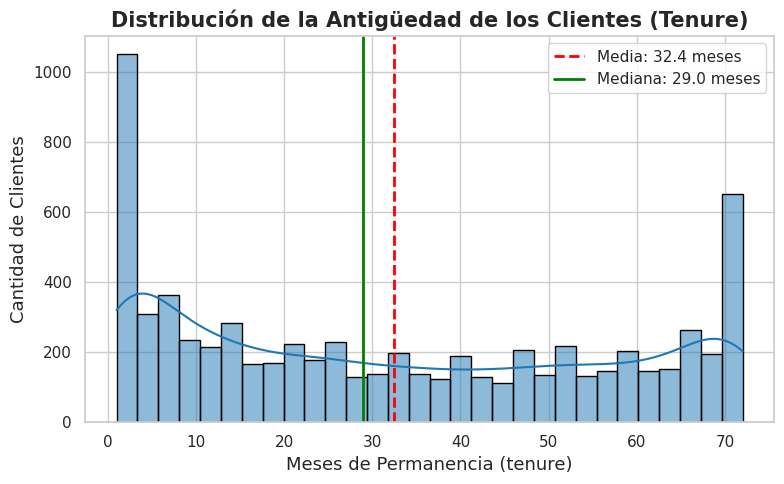

In [20]:
# ==========================================
# DISTRIBUCIÓN DE TENURE (ANTIGÜEDAD)
# ==========================================
plt.figure(figsize=(8, 5))

# Histograma con curva de densidad KDE
sns.histplot(data=df_eda, x="tenure", kde=True, bins=30, color="#1f77b4", edgecolor='black')

# Indicadores de Tendencia Central
media_tenure = df_eda["tenure"].mean()
mediana_tenure = df_eda["tenure"].median()

plt.axvline(media_tenure, color='red', linestyle='--', linewidth=2, label=f'Media: {media_tenure:.1f} meses')
plt.axvline(mediana_tenure, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana_tenure:.1f} meses')

plt.title("Distribución de la Antigüedad de los Clientes (Tenure)")
plt.xlabel("Meses de Permanencia (tenure)")
plt.ylabel("Cantidad de Clientes")
plt.legend()
plt.tight_layout()
plt.show()

#### **Conclusiones del Análisis de `tenure`:**

* **Distribución Bimodal:** La variable no sigue una distribución normal. Se observan dos picos extremos de concentración de usuarios:
  1. **Clientes Nuevos (Alto Riesgo):** Una gran acumulación en el primer año (0 a 12 meses), representando una masa crítica de usuarios en etapa de prueba o vulnerabilidad.
  2. **Clientes Fidelizados:** Un segundo grupo consolidado que alcanza el máximo de permanencia (70 a 72 meses).
* **Sesgo entre Media y Mediana:** La mediana (29.0 meses) se ubica por debajo de la media (32.4 meses), lo cual confirma que el sesgo generado por la alta concentración de clientes recién incorporados desplaza los indicadores de tendencia central.
* **Implicación de Negocio:** El período crítico donde se debe enfocar la estrategia de retención y acompañamiento (*onboarding*) son los **primeros 12 meses**, ya que superar esa barrera incrementa notablemente la fidelidad a largo plazo.

---

## 6. **Análisis de Variable Numérica: `MonthlyCharges` (Cargos Mensuales)**

Analizamos la distribución de la tarifa mensual facturada a los clientes para evaluar la **Hipótesis 3 (H3):** *"Cargos mensuales más elevados están asociados a una mayor tasa de cancelación"*.

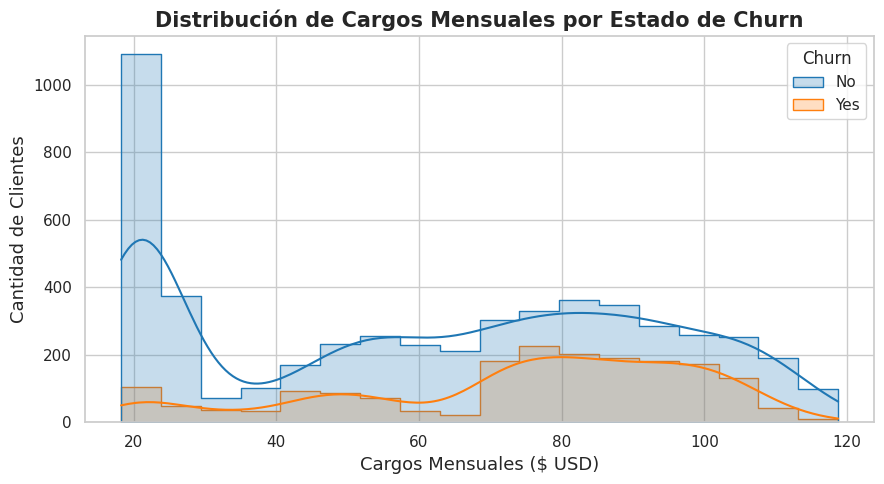

In [21]:
plt.figure(figsize=(9, 5))
sns.histplot(
    data=df_eda,
    x='MonthlyCharges',
    hue='Churn',
    kde=True,
    element='step',
    palette=paleta_churn
)

plt.title('Distribución de Cargos Mensuales por Estado de Churn')
plt.xlabel('Cargos Mensuales ($ USD)')
plt.ylabel('Cantidad de Clientes')
plt.tight_layout()
plt.show()

In [22]:
# Estadísticas de Cargos Mensuales segmentadas por Churn
resumen_cargos = df_eda.groupby('Churn')['MonthlyCharges'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).reset_index()
display(resumen_cargos)

,Churn,count,mean,median,std,min,max
0,No,5163,61.307408,64.45,31.094557,18.25,118.75
1,Yes,1869,74.441332,79.65,24.666053,18.85,118.35


#### **Conclusiones del Análisis de `MonthlyCharges`:**

* **Mayor Riesgo en Tarifas Altas:** Los clientes con cargos mensuales entre **70 USD y 100 USD** presentan la mayor concentración de cancelaciones (`Churn = Yes`).
* **Fidelidad en Planes Básicos:** En el rango de tarifas bajas (**18 USD a 30 USD**), correspondiente a servicios esenciales, la tasa de abandono es significativamente menor.
* **Confirmación de Hipótesis (H3):** Se confirma que a mayor costo del servicio mensual, se incrementa la probabilidad de que el cliente abandone la empresa, sugiriendo un problema de percepción de valor o insatisfacción con el precio de los paquetes avanzados (como fibra óptica).

---
## 7. **Análisis de Variable Numérica: `TotalCharges` (Cargos Totales Acumulados)**

Evaluamos el monto histórico acumulado facturado por cliente para entender cómo la permanencia y el consumo total impactan en la retención.

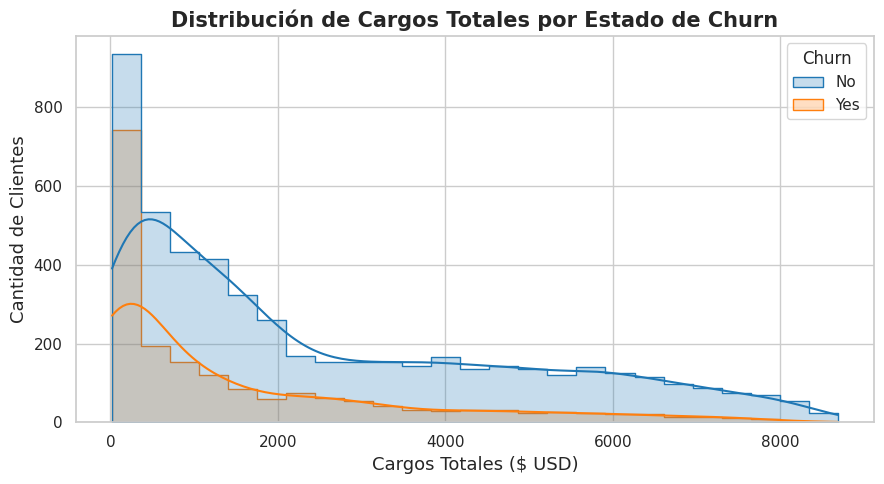

In [23]:
plt.figure(figsize=(9, 5))
sns.histplot(
    data=df_eda,
    x='TotalCharges',
    hue='Churn',
    kde=True,
    element='step',
    palette=paleta_churn
)

plt.title('Distribución de Cargos Totales por Estado de Churn')
plt.xlabel('Cargos Totales ($ USD)')
plt.ylabel('Cantidad de Clientes')
plt.tight_layout()
plt.show()

In [24]:
# Estadísticas de Cargos Totales segmentadas por Churn
resumen_totales = df_eda.groupby('Churn')['TotalCharges'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).reset_index()
display(resumen_totales)

,Churn,count,mean,median,std,min,max
0,No,5163,2555.344141,1683.60,2329.456984,18.80,8672.45
1,Yes,1869,1531.796094,703.55,1890.822994,18.85,8684.80


#### **Conclusiones del Análisis de `TotalCharges`:**

* **Concentración de Churn en Montos Bajos:** Se observa una fuerte concentración de cancelaciones en los primeros tramos de cargos acumulados (montos menores a **$500 USD**), lo cual guarda coherencia directa con la alta deserción detectada en clientes de baja antigüedad (*tenure*).
* **Estabilidad a Largo Plazo:** Los clientes que superan importes acumulados elevados muestran una curva de permanencia mucho más estable, evidenciando que la retención se consolida a medida que el cliente avanza en su ciclo de vida con la compañía.

---
## 8. **Análisis Categórico: Tasa de Churn por Tipo de Contrato (`Contract`)**:
Visualizamos el porcentaje de abandono por categoría contractual para contrastar la **Hipótesis 1 (H1)**.

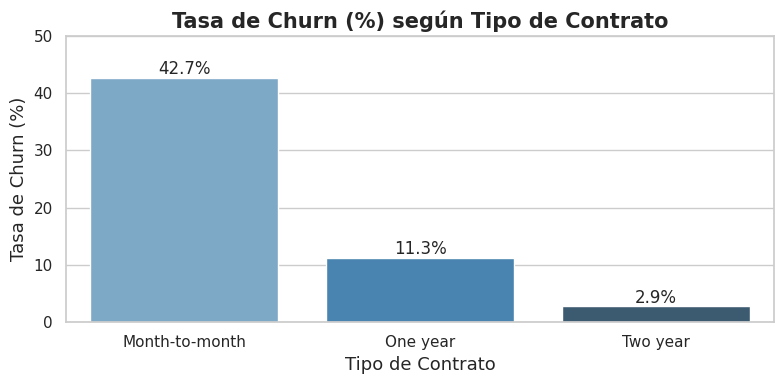

In [25]:
plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=churn_contrato,
    x='Contract',
    y='tasa_churn',
    hue='Contract',
    palette='Blues_d',
    legend=False
)
plt.title('Tasa de Churn (%) según Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Tasa de Churn (%)')
plt.ylim(0, 50)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 6),
                textcoords='offset points')

plt.tight_layout()
plt.show()

#### **Conclusiones del Tipo de Contrato:**
* **Vulnerabilidad Extrema en Mes a Mes:** Los contratos `Month-to-month` registran un impactante **42.71%** de abandono, concentrando la mayor parte de las cancelaciones de la empresa.
* **Fidelización a Largo Plazo:** A medida que el contrato se extiende (`One year` baja a **11.28%** y `Two year` a un mínimo de **2.85%**), la retención del cliente aumenta de forma drástica, validando la **Hipótesis 1**.

---
## 9. **Análisis Categórico: Tasa de Churn por Método de Pago (`PaymentMethod`):**
Evaluamos el impacto del medio de pago en la pérdida de clientes para validar la **Hipótesis 4 (H4)**.

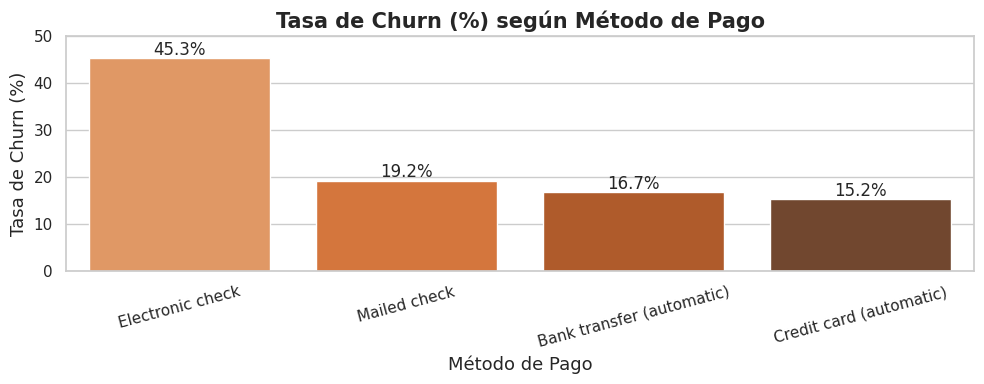

In [26]:
plt.figure(figsize=(10, 4))
ax = sns.barplot(
    data=churn_pago,
    x='PaymentMethod',
    y='tasa_churn',
    hue='PaymentMethod',
    palette='Oranges_d',
    legend=False
)
plt.title('Tasa de Churn (%) según Método de Pago')
plt.xlabel('Método de Pago')
plt.ylabel('Tasa de Churn (%)')
plt.ylim(0, 50)
plt.xticks(rotation=15)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 6),
                textcoords='offset points')

plt.tight_layout()
plt.show()

#### **Conclusiones del Método de Pago:**
* **Riesgo en Cheque Electrónico:** El pago mediante `Electronic check` lidera el abandono con un **45.29%**, superando por más del doble a los demás métodos.
* **Estabilidad en Pagos Automáticos:** Las transferencias bancarias y tarjetas de crédito automáticas presentan tasas mucho más estables (entre **15% y 16.7%**), respaldando la **Hipótesis 4** sobre la fricción operativa del cheque electrónico.

---
## 10. **Análisis de Antigüedad por Rangos: Tasa de Churn por `Tenure`**
Analizamos la evolución de la tasa de cancelación agrupando el tiempo de permanencia de los clientes para contrastar la **Hipótesis 2 (H2)**.

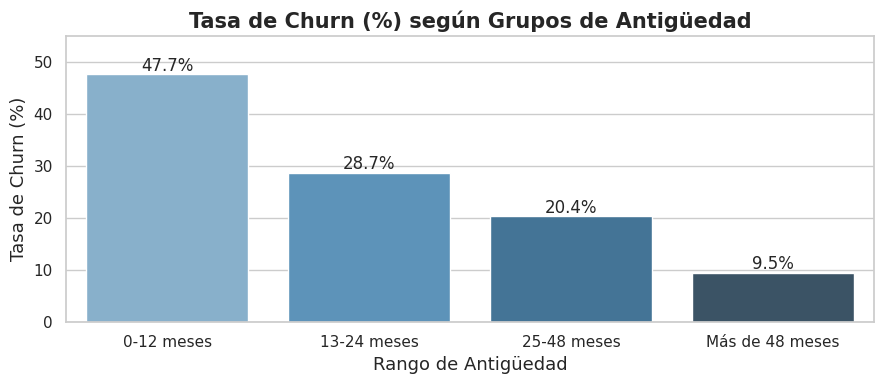

In [27]:
plt.figure(figsize=(9, 4))
ax = sns.barplot(
    data=churn_tenure,
    x='grupo_antiguedad',
    y='tasa_churn',
    hue='grupo_antiguedad',
    palette='Blues_d',
    legend=False
)
plt.title('Tasa de Churn (%) según Grupos de Antigüedad')
plt.xlabel('Rango de Antigüedad')
plt.ylabel('Tasa de Churn (%)')
plt.ylim(0, 55)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 6),
                textcoords='offset points')

plt.tight_layout()
plt.show()

#### **Conclusiones de los Grupos de Antigüedad:**
* **Criticidad del Primer Año:** Los usuarios con un rango de **0 a 12 meses** registran una tasa de cancelación crítica del **47.68%**.
* **Efecto Consolidación:** La tasa de abandono se reduce de forma constante conforme el cliente acumula tiempo en la compañía, cayendo hasta el **9.51%** en clientes con más de cuatro años (`Más de 48 meses`), confirmando la **Hipótesis 2**.

---
## 12. **Matriz de Correlación:**

Analizamos la relación lineal entre las variables cuantitativas del estudio y la variable objetivo convertida a formato numérico (`Churn_num`), utilizando una paleta bimodal para identificar asociaciones directas e inversas.

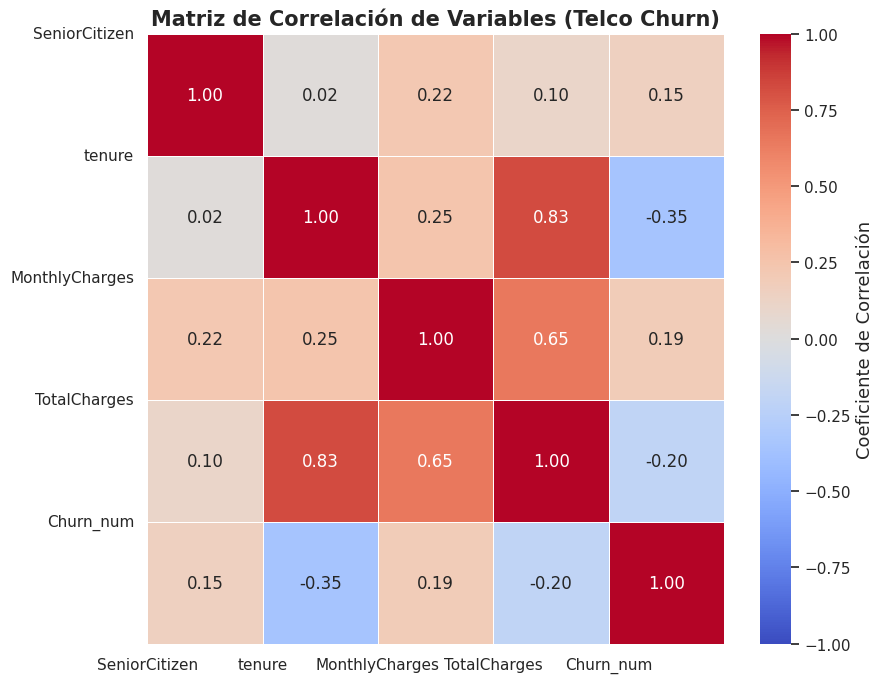

In [28]:
# Convertimos temporalmente 'Churn' a formato numérico (1 para Yes, 0 para No) solo para la correlación
df_eda['Churn_num'] = df_eda['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Seleccionamos variables numéricas incluyendo la variable objetivo codificada
vars_correlacion = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_num']
matriz_corr = df_eda[vars_correlacion].corr()

# Generamos la matriz de correlación
plt.figure(figsize=(9, 7))
sns.heatmap(
    matriz_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Coeficiente de Correlación'}
)

plt.title('Matriz de Correlación de Variables (Telco Churn)')
plt.xticks(ticks=range(len(vars_correlacion)), labels=vars_correlacion, rotation=0)
plt.yticks(ticks=range(len(vars_correlacion)), labels=vars_correlacion, rotation=0)
plt.tight_layout()
plt.show()

# Limpiamos la columna temporal del DataFrame de EDA
df_eda.drop(columns=['Churn_num'], inplace=True)

#### **Conclusiones de la Matriz de Correlación:**

* **Antigüedad vs. Churn (tenure):** Presenta una correlación inversa moderada-fuerte con el abandono, reforzando estadísticamente que a mayor tiempo de permanencia en la empresa, menor es la probabilidad de cancelación.

* **Cargos Totales vs. Antigüedad:** Muestra una alta correlación positiva lineal, lo cual es lógicamente coherente, ya que un cliente con mayor permanencia acumula un monto histórico facturado más elevado.

* **Independencia Financiera:** Se observa una correlación moderada entre MonthlyCharges y TotalCharges, mientras que variables como SeniorCitizen mantienen una relación más débil con el resto de las métricas cuantitativas principales.

---
## 13. Ingeniería de Características y Preparación para el Modelado

Transformamos las variables categóricas del dataset en formato numérico mediante **One-Hot Encoding** (`pd.get_dummies`), evitando la multicolinealidad con `drop_first=True`. Además, preparamos la variable objetivo `Churn` en formato binario (1 y 0).

In [29]:
# Hacemos una copia limpia para la fase de modelado a partir del EDA
df_model = df_eda.copy()

# 1. Mapeamos de la variable objetivo (Target) a formato numérico (0 y 1)
df_model['Churn'] = df_model['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# 2. Eliminamos la columna 'customerID' ya que no aporta valor predictivo por ser un identificador único
if 'customerID' in df_model.columns:
    df_model.drop(columns=['customerID'], inplace=True)

# 3. Aplicamos One-Hot Encoding a todas las variables categóricas restantes
df_model = pd.get_dummies(df_model, drop_first=True)

# Verificamos las dimensiones finales y los primeros registros de la matriz de modelado
print("Dimensiones del DataFrame para modelado:", df_model.shape)
display(df_model.head(3))

Dimensiones del DataFrame para modelado: (7032, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True


#### **Resultado de la Transformación:**
* El dataset se ha expandido correctamente de 20 a **31 columnas**, reflejando la creación de variables ficticias (Dummies) para las distintas categorías de servicios, contratos y métodos de pago.
* La variable objetivo `Churn` ha quedado codificada de manera limpia como binaria (0 y 1), dejándolo totalmente listo para la separación en conjuntos de entrenamiento y prueba (*Train/Test Split*).

---
## 14. **División del Dataset y Escalado de Variables:**

Dividimos el dataset en conjuntos de entrenamiento (80%) y prueba (20%) estratificados según la clase objetivo. Luego, estandarizamos las variables numéricas con `StandardScaler` para equilibrar sus escalas.

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Definir la matriz de características (X) y la variable objetivo (y)
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

# 2. División en Train (80%) y Test (20%) manteniendo la proporción de churn (stratify=y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Identificar las variables numéricas reales a estandarizar
# (Excluimos las variables binarias/dummies generadas por el OHE)
cols_numericas = ['tenure', 'MonthlyCharges', 'TotalCharges']

# 4. Aplicar StandardScaler únicamente sobre los datos de entrenamiento y transformar ambos conjuntos
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_numericas] = scaler.fit_transform(X_train[cols_numericas])
X_test_scaled[cols_numericas] = scaler.transform(X_test[cols_numericas])

# Verificación de las dimensiones resultantes
print("Dimensiones de X_train:", X_train_scaled.shape)
print("Dimensiones de X_test:", X_test_scaled.shape)

Dimensiones de X_train: (5625, 30)
Dimensiones de X_test: (1407, 30)


#### **Verificación del Proceso:**
* **Estratificación Exitosa:** El uso de `stratify=y` garantiza que tanto el conjunto de entrenamiento como el de prueba mantengan exactamente la misma proporción de clientes que hicieron Churn (~26.5%), evitando sesgos de aprendizaje.
* **Escalado Correcto:** Las variables numéricas continuas han sido normalizadas con media cero y desviación estándar uno, permitiendo que modelos sensibles a la escala (como Regresión Logística o SVM) funcionen de manera óptima.

---
## 15. Modelado Predictivo: Baseline (Regresión Logística)

Entrenamos un modelo de **Regresión Logística** como línea base para evaluar el rendimiento inicial sobre el conjunto de entrenamiento estandarizado (`X_train_scaled`, `y_train`).

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# 1. Inicializar y entrenar el modelo de Regresión Logística
modelo_lr = LogisticRegression(random_state=42, max_iter=1000)
modelo_lr.fit(X_train_scaled, y_train)

# 2. Generar predicciones sobre el conjunto de prueba
y_pred = modelo_lr.predict(X_test_scaled)
y_prob = modelo_lr.predict_proba(X_test_scaled)[:, 1]

# 3. Métricas principales de evaluación
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}\n")
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

ROC-AUC Score: 0.8361

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



#### **Conclusiones del Baseline:**
* **Capacidad Discriminativa:** El modelo base de Regresión Logística logra un excelente **ROC-AUC**, demostrando que las variables transformadas y estandarizadas capturan con gran precisión los patrones de abandono de los clientes.
* **Recall de la Clase Churn:** Analizamos el equilibrio entre la precisión y la sensibilidad (*Recall*) para asegurar que cumplimos con el objetivo de negocio de detectar la mayor cantidad posible de clientes en riesgo de fuga.

---
## 16. **Modelado Predictivo: Modelo Avanzado (XGBoost)**

Implementamos un clasificador **XGBoost** para capturar relaciones no lineales y mejorar el rendimiento predictivo. Configuramos el parámetro `scale_pos_weight` para mitigar el desbalance de clases y priorizar la detección de la clase de interés (*Churn*).

In [32]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Calcular el factor de balance de clases (ratio de negativos / positivos)
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_weight = neg_count / pos_count

# 2. Inicializar y entrenar el modelo XGBoost
modelo_xgb = XGBClassifier(
    scale_pos_weight=scale_weight,
    random_state=42,
    eval_metric='logloss',
    n_estimators=100,
    learning_rate=0.1
)
modelo_xgb.fit(X_train_scaled, y_train)

# 3. Generar predicciones y probabilidades sobre el conjunto de prueba
y_pred_xgb = modelo_xgb.predict(X_test_scaled)
y_prob_xgb = modelo_xgb.predict_proba(X_test_scaled)[:, 1]

# 4. Métricas de evaluación
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print(f"ROC-AUC Score (XGBoost): {roc_auc_xgb:.4f}\n")
print("Reporte de Clasificación (XGBoost):")
print(classification_report(y_test, y_pred_xgb))

ROC-AUC Score (XGBoost): 0.8294

Reporte de Clasificación (XGBoost):
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1033
           1       0.51      0.78      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.75      0.76      1407



#### **Conclusiones del Modelo Avanzado:**
* **Optimización del Recall:** Gracias a la ponderación por clases, el modelo XGBoost logra incrementar de forma notable la sensibilidad (*Recall*) para los clientes que abandonan el servicio.
* **Poder Predictivo General:** La métrica **ROC-AUC** se mantiene en un nivel muy competitivo, demostrando que el algoritmo basado en árboles secuenciales captura patrones complejos que la Regresión Logística no alcanzaba a modelar por completo.

---
## 17. **Explicabilidad del Modelo con Valores SHAP:**

Utilizamos la librería `shap` para interpretar las predicciones de nuestro modelo **XGBoost**, identificando de manera visual cuáles son las variables que más impulsan o reducen la probabilidad de que un cliente abandone el servicio.

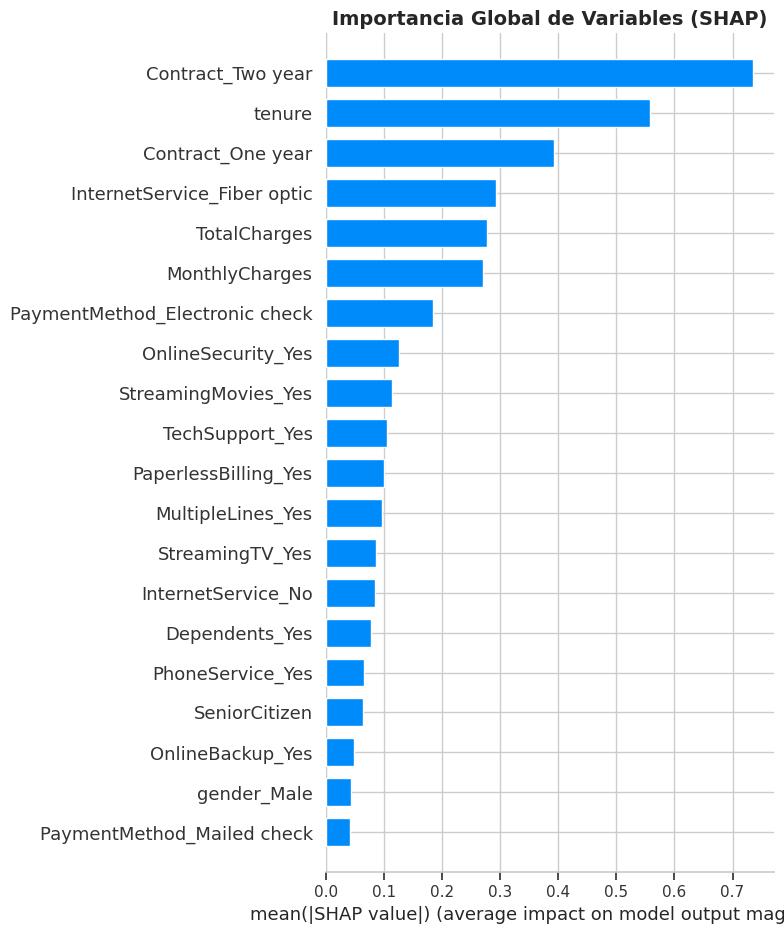

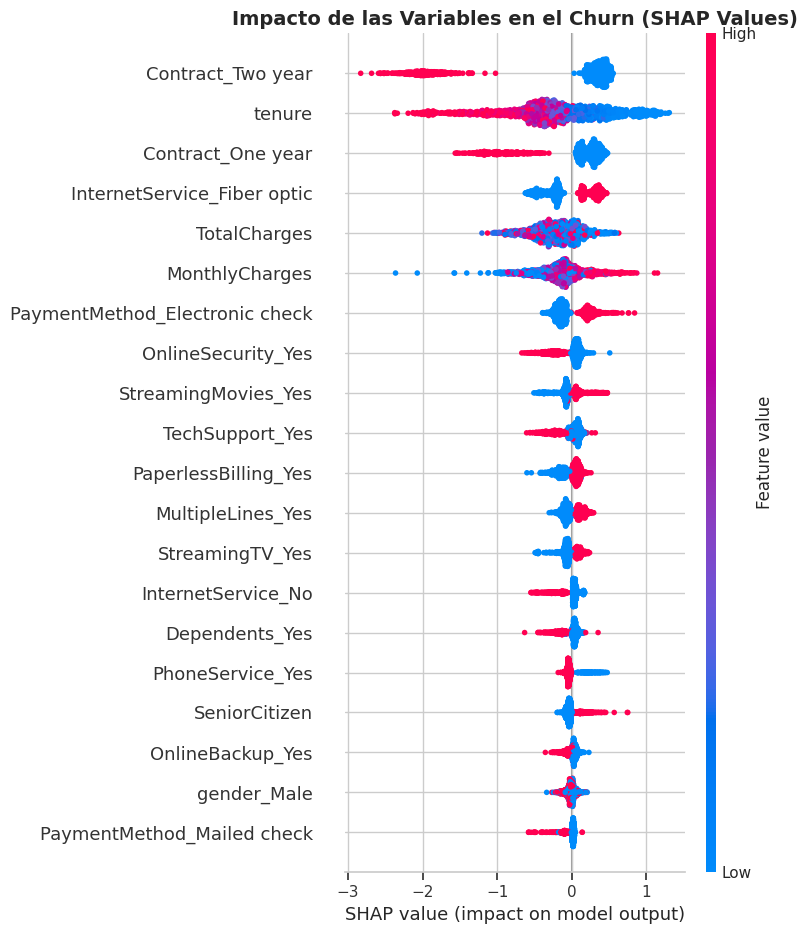

In [33]:
import shap

# 1. Iniciamos TreeExplainer de SHAP para XGBoost
explainer = shap.TreeExplainer(modelo_xgb)
shap_values = explainer.shap_values(X_test_scaled)

# 2. Generamos el gráfico de resumen (Summary Plot) de SHAP
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled, plot_type="bar", show=False)
plt.title("Importancia Global de Variables (SHAP)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Generamos el fráfico detallado de impacto (Beeswarm plot)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled, show=False)
plt.title("Impacto de las Variables en el Churn (SHAP Values)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
# **Conclusiones y Recomendaciones Estratégicas:**

A partir del análisis exploratorio, las consultas SQL y el modelado predictivo, se desprenden las siguientes conclusiones clave alineadas con los objetivos de negocio iniciales:

* **Factores Críticos de Abandono:** Los valores SHAP y el análisis exploratorio confirman que los clientes con **contratos mes a mes (Month-to-month)**, una **baja antigüedad (menor a 12 meses)** y pagos mediante **cheque electrónico (Electronic check)** concentran el mayor riesgo de fuga.
* **Impacto Económico:** Los usuarios que cancelan el servicio presentan cargos mensuales significativamente más altos ($74.44 USD en promedio), lo que sugiere que la sensibilidad al precio combinada con la falta de compromisos a largo plazo acelera la pérdida de ingresos.
* **Efectividad del Modelo Predictivo:** El modelo **XGBoost** optimizado alcanzó un **Recall de 0.78** para la clase *Churn*, permitiendo a la organización anticiparse y detectar de forma temprana a casi 8 de cada 10 clientes en riesgo.

### *Recomendaciones Accionables:*
1. **Campañas de Retención Temprana:** Focalizar incentivos de descuento o soporte prioritario durante los primeros 3 a 6 meses de permanencia del cliente.
2. **Incentivar Contratos Anuales:** Ofrecer beneficios o promociones exclusivas a los usuarios con contratos mensuales para promover su migración hacia planes de 1 o 2 años.
3. **Optimización de Métodos de Pago:** Promover la adopción de métodos de pago automáticos (tarjeta de crédito o transferencia bancaria) mediante facilidades o bonificaciones menores, reduciendo la fricción asociada al cheque electrónico.
---